In [387]:
import os
from pathlib import Path

import ee
import geemap
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import rasterio as rio
import rasterio.sample as rio_sample
import seaborn as sns
from psmpy import PsmPy

In [3]:
ee.Initialize()

In [4]:
data_path = Path(os.environ["DATA_PATH"])

# Bounds

In [5]:
df_bounds = (
    gpd.read_file(
        data_path / "Areas de intervenção" / "Mancha Urbana" / "MANCHA_URBANA_2018",
    )
    .pipe(lambda df: df.to_crs(df.estimate_utm_crs()))
    .explode()
    .assign(area=lambda df: df["geometry"].area)
    .sort_values("area", ascending=False)
    .head(1)
    .assign(geometry=lambda df: df["geometry"].simplify(10))
    .filter(["geometry"])
    .to_crs("EPSG:4326")
)

bounds_ee = geemap.geopandas_to_ee(df_bounds).first().geometry()

# Temperature

In [218]:
def extract_bits(img: ee.image.Image, from_bit: int, to_bit: int) -> ee.image.Image:
    mask_size = ee.Number(1).add(to_bit).subtract(from_bit)
    mask = ee.Number(1).leftShift(mask_size).subtract(1)
    return img.rightShift(from_bit).bitwiseAnd(mask)


def mask_clouds(img: ee.image.Image) -> ee.image.Image:
    qa = img.select("QA_PIXEL")
    mask = extract_bits(qa, 1, 4).eq(0)
    return img.updateMask(mask)


def get_lst(year: int, temp_band: str, qa_band: str) -> ee.image.Image:
    col = (
        ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
        .filterBounds(bounds_ee)
        .filterDate(f"{year}-12-01", f"{year + 1}-03-01")
        .select([temp_band, qa_band])
    )

    return (
        col.map(mask_clouds)
        .select(temp_band)
        .map(lambda img: img.multiply(0.00341802).add(149 - 273.15))
        .mean()
        .rename(f"b{year}")
    )

In [219]:
test = get_lst(year=2000, temp_band="ST_B6", qa_band="QA_PIXEL")

m = geemap.Map(center=[-19.9207, -43.9378], zoom=12)
m.addLayer(test.select("b2000").clip(bounds_ee))
m

Map(center=[-19.9207, -43.9378], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [230]:
lst = get_lst(year=2000, temp_band="ST_B6", qa_band="QA_PIXEL")

for year in range(2001, 2020):
    lst = lst.addBands(get_lst(year=year, temp_band="ST_B6", qa_band="QA_PIXEL"))

# Greening

In [269]:
img = (
    ee.imagecollection.ImageCollection("users/Caoyue/greening/Green_B")
    .filterBounds(bounds_ee)
    .mosaic()
)

gain_yod = img.select("gain_yod")
loss_yod = img.select("loss_yod")
mix = gain_yod.updateMask(loss_yod.gt(0)).unmask(0)

greening = gain_yod.updateMask(mix.eq(0)).clamp(0, 1).rename("type")
browning = loss_yod.updateMask(mix.eq(0)).clamp(0, 1).multiply(2).rename("type")
joined = greening.unmask().add(browning.unmask(0)).selfMask()

# Samples

## Points

In [434]:
df_samples = (
    ee.data.computeFeatures(
        {
            "expression": ee.image.Image.constant(1)
            .addBands(joined)
            .stratifiedSample(
                numPoints=500,
                classBand="type",
                region=bounds_ee,
                scale=30,
                geometries=True,
                seed=42,
            ),
            "fileFormat": "GEOPANDAS_GEODATAFRAME",
        },
    )
    .drop(columns=["constant"])
    .pipe(lambda df: df.set_crs("EPSG:4326"))
    .assign(type=lambda df: df["type"].map({1: 1, 2: 0}))
)

crs = df_samples.estimate_utm_crs()
df_samples = df_samples.to_crs(crs)

col_samples = geemap.geopandas_to_ee(
    df_samples.to_crs("EPSG:4326")[["geometry"]].reset_index(names="index"),
)

## Temperature

In [436]:
start_end_temps = (
    ee.data.computeFeatures(
        {
            "expression": lst.select(["b2000", "b2019"]).sampleRegions(
                col_samples, scale=30,
            ),
            "fileFormat": "GEOPANDAS_GEODATAFRAME",
        },
    )
    .set_index("index")
    .drop(columns=["geometry"])
    .rename(columns={"b2000": "start_temp", "b2019": "end_temp"})
)

df_samples = df_samples.drop(columns=["start_temp", "end_temp"], errors="ignore").join(
    start_end_temps,
)

Text(0.5, 0, 'Temperature Change (°C)')

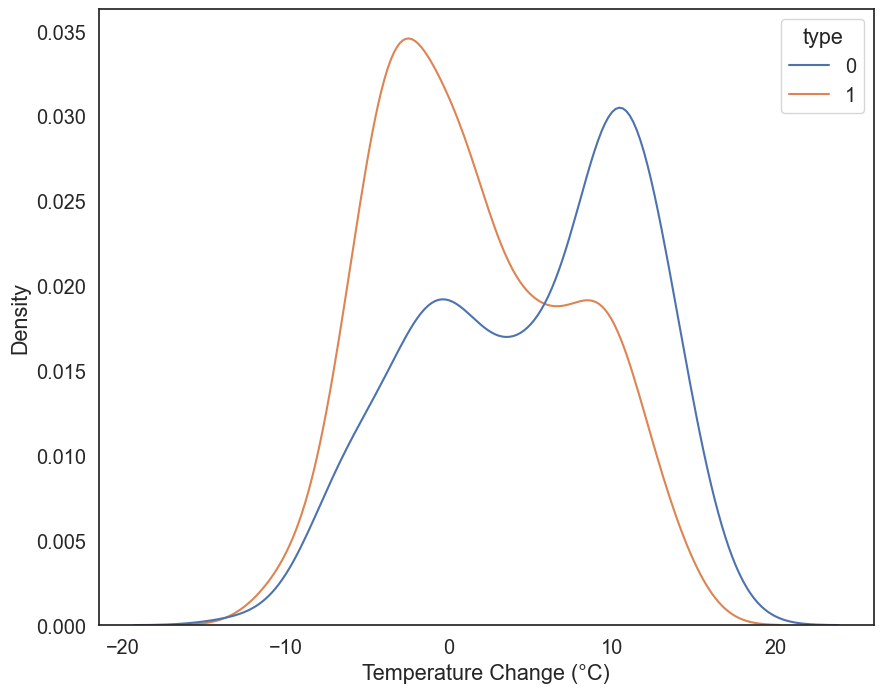

In [438]:
sns.kdeplot(df_samples.assign(diff=lambda df: df["end_temp"] - df["start_temp"]), x="diff", hue="type")
plt.xlabel("Temperature Change (°C)")

## Elevation

In [418]:
df_level = (
    gpd.read_file(
        data_path / "Areas de intervenção" / "Altimetria_MDT" / "CURVA_DE_NIVEL_5M",
    )
    .pipe(lambda df: df.to_crs(crs))
    .filter(["COTA", "geometry"])
    .rename(columns={"COTA": "elevation"})
)

df_samples = (
    df_samples.drop(columns=["index_right", "elevation"], errors="ignore")
    .sjoin_nearest(df_level)
    .drop(columns=["index_right"])
)

## Slope

In [419]:
with rio.open(data_path / "Ide_bhgeo_mosaico-declividade_curva_nivel_2015.tif") as ds:
    coords = [(geom.x, geom.y) for geom in df_samples.geometry]
    slope_values = list(rio_sample.sample_gen(ds, coords))
    df_samples = df_samples.assign(slope=[val[0] for val in slope_values])

## Matching

In [421]:
not_matched = (
    df_samples.reset_index(names="index")
    .drop(columns=["geometry"])
    .dropna(subset=["start_temp"])
)

psm = PsmPy(
    not_matched,
    treatment="type",
    indx="index",
    exclude=["end_temp"],
    seed=42,
)
psm.logistic_ps(balance=True)
psm.kdtree_matched(
    matcher="propensity_logit", replacement=False, caliper=0.05, drop_unmatched=True,
)

<Axes: xlabel='propensity_logit', ylabel='Density'>

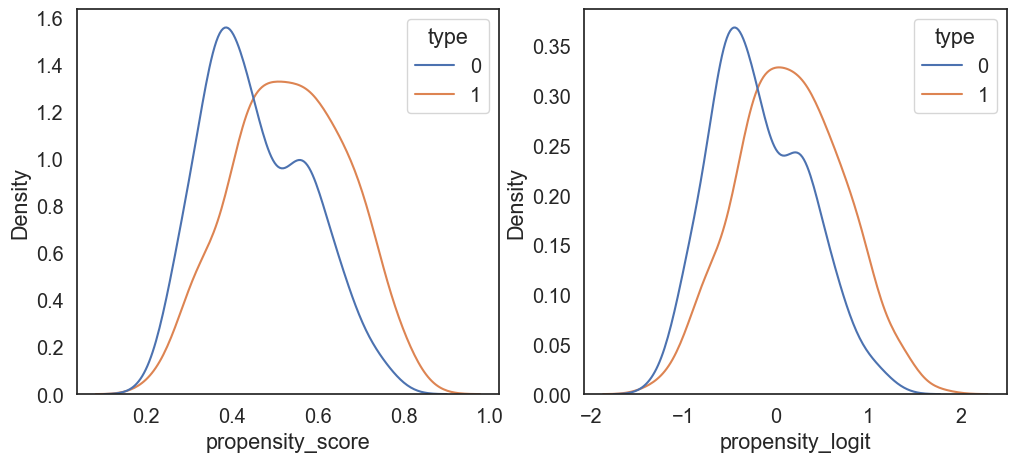

In [422]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(psm.predicted_data, hue="type", x="propensity_score", ax=axl)
sns.kdeplot(psm.predicted_data, hue="type", x="propensity_logit", ax=axr)

In [423]:
matched_treatment = df_samples.loc[psm.matched_ids["matched_ID"]]
matched_control = df_samples.loc[psm.matched_ids["index"]]
matched = pd.concat([matched_treatment, matched_control])

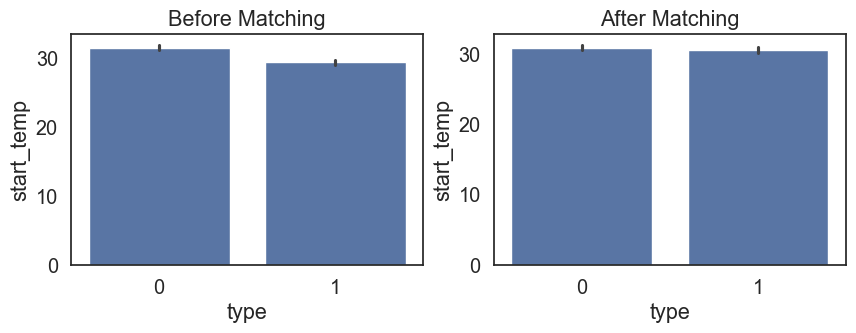

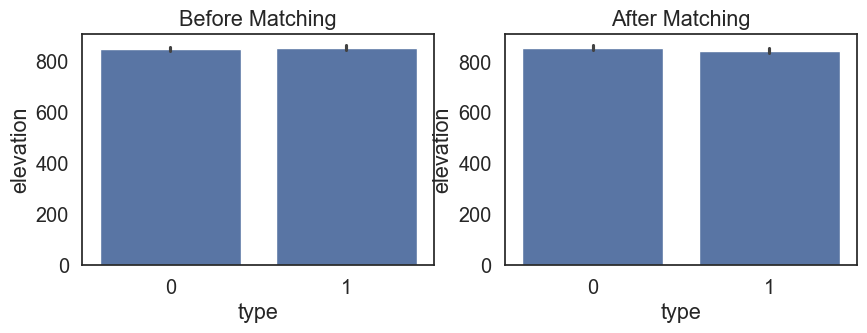

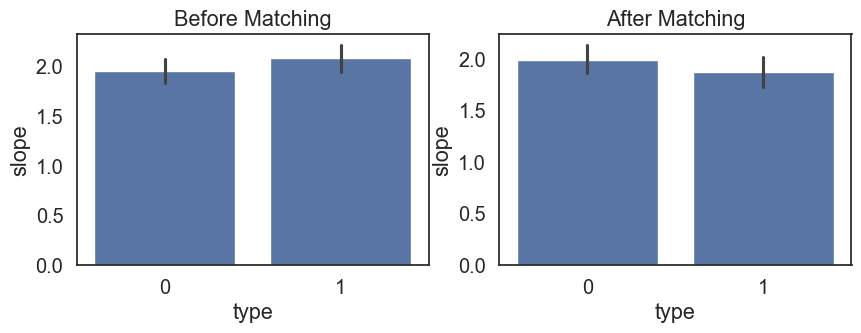

In [446]:
for var in ["start_temp", "elevation", "slope"]:
    fig, (axl, axr) = plt.subplots(1, 2, figsize=(10, 3))
    sns.barplot(data=not_matched, y=var, x="type", ax=axl)
    sns.barplot(data=matched, y=var, x="type", ax=axr)
    axl.set_title("Before Matching")
    axr.set_title("After Matching")

<Axes: xlabel='end_temp'>

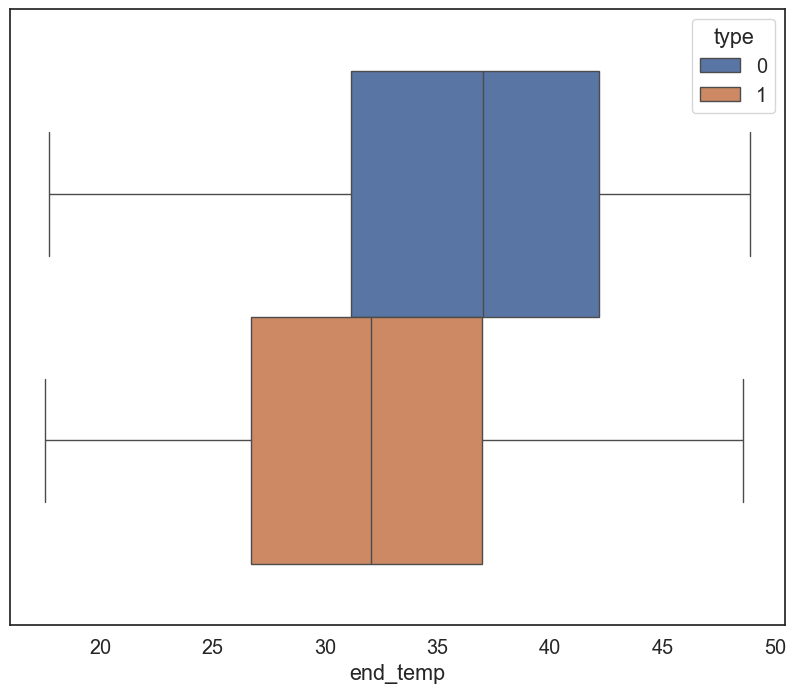

In [447]:
test = matched.assign(diff=lambda df: df["start_temp"] - df["end_temp"])
sns.boxplot(test, x="end_temp", hue="type")

In [432]:
test.groupby("type")["diff"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
0,223.0,5.728131,6.447056,-12.829538,0.520394,7.047957,10.783853,17.414812
1,223.0,1.601488,6.036583,-10.161773,-3.359059,0.483650,7.106064,14.393282


,ID_CN5M,COTA,geometry
0,33195.0,820.0,"LINESTRING (608286.357 7801455.457, 608286.802..."
1,33196.0,820.0,"LINESTRING (613277.871 7801380.353, 613282.052..."
2,33197.0,820.0,"LINESTRING (613776.465 7801175.634, 613776.3 7..."
3,33198.0,820.0,"LINESTRING (608319.538 7801079.394, 608318.911..."
4,33199.0,820.0,"LINESTRING (609719.979 7800897.651, 609720.804..."
...,...,...,...
3694,34598.0,700.0,"LINESTRING (619426.715 7804035.982, 619425.099..."
3695,34599.0,700.0,"LINESTRING (619615.916 7803982.803, 619615.834..."
3696,34600.0,695.0,"LINESTRING (615737.648 7808150.345, 615737.401..."
3697,34601.0,695.0,"LINESTRING (615587.582 7808084.068, 615587.293..."


<Axes: xlabel='diff'>

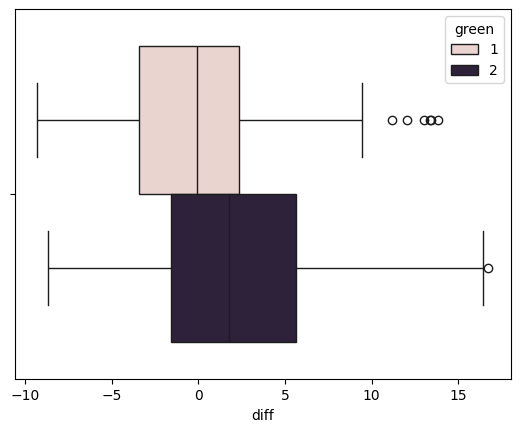

In [238]:
temp = sample.assign(diff=lambda df: df["b2019"] - df["b2000"])
sns.boxplot(data=temp, hue="green", x="diff")

In [16]:
m = geemap.Map(center=[-19.9207, -43.9378], zoom=12)
m.addLayer(
    joined.clip(bounds_ee),
    {"bands": ["type"], "min": 1, "max": 2, "palette": ["green", "brown"]},
)
m

Map(center=[-19.9207, -43.9378], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…